# Project Objective 1: Identify factors that influence whether a family falls behind on their payments

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clients = pd.read_csv('client_data_20250423120102.csv')
repayment = pd.read_csv('repayment_data_20250423120137.csv')
payments = pd.read_csv('payments_data_20250423120157.csv')
reconciled = pd.read_csv('reconciled_payment_data_20250423120155.csv')
reversed_payments = pd.read_csv('reversed_payments_data_20250423120248.csv')
interaction = pd.read_csv('interaction_data_20250423120206.csv')
user = pd.read_csv('user_data_20250423120106.csv')
village = pd.read_csv('village_data_20250423120201.csv')
contracts = pd.read_csv('contract_event_data_20250423120141.csv')
Addon_offer = pd.read_csv('add_on_offer_data_20250423120251.csv')
Addon = pd.read_csv('add_on_offer_data_20250423120251.csv')
product = pd.read_csv('product_subtypes_data_20250423120242.csv')
offers = pd.read_csv('offers_data_20250423120143.csv')



In [ ]:
# Step 1: Add default indicator
clients['defaulted'] = clients['Has Defaulted Contracts'].astype(bool).astype(int)



In [ ]:
# Step 2: Aggregate repayment data
#We aggregated repayment data to transform raw payment logs into meaningful client-level features that capture payment behavior over time.
#These features (e.g., lateness, total paid) help the model identify patterns linked to default risk.

repayment['Expected Payment Date'] = pd.to_datetime(repayment['Expected Payment Date'], errors='coerce')
repayment_agg = repayment.groupby('Client Id').agg({
    'Days Late': ['mean', 'max'],
    'Amount Paid': 'sum',
    'Total Amount': 'sum',
    'Id': 'count'
}).reset_index()
repayment_agg.columns = ['Client Id', 'avg_days_late', 'max_days_late', 'total_paid', 'total_due', 'num_payments']

# Step 3: Aggregate reconciled payments
reconciled_agg = reconciled.groupby('Client Id')['Amount'].sum().reset_index()
reconciled_agg.columns = ['Client Id', 'total_verified_paid']

# Step 4: Map reversed payments to clients via reconciled
reversed_with_client = reversed_payments.merge(reconciled[['Id', 'Client Id']], left_on='Payment Id', right_on='Id', how='left')
reversal_count = reversed_with_client.groupby('Client Id')['Reversal Id'].count().reset_index()
reversal_count.columns = ['Client Id', 'num_reversals']

# Step 5: Count interactions
interaction_count = interaction.groupby('Client Id')['Id'].count().reset_index()
interaction_count.columns = ['Client Id', 'interaction_count']

# Step 6: Guardian Info
guardian = user[['Id', 'Role', 'Reference Entity Name']].rename(columns={'Id': 'User In Charge Id'})

# Merge all components
df = clients.merge(repayment_agg, how='left', left_on='Id', right_on='Client Id')
df = df.merge(reconciled_agg, how='left', on='Client Id')
df = df.merge(reversal_count, how='left', on='Client Id')
df = df.merge(interaction_count, how='left', on='Client Id')
df = df.merge(guardian, how='left', on='User In Charge Id')




In [ ]:
# Drop columns with more than 500 nulls
null_counts = df.isnull().sum()
cols_to_drop = null_counts[null_counts > 500].index.tolist()
cleaned_df = df.drop(columns=cols_to_drop)

cleaned_df.head()


,Id,First Name,Family Name,Gender,Primary Phone Number,All Phone Numbers,Start Date,Has Active Contracts,Has Completed Contracts,Has Defaulted Contracts,...,Last Updated,defaulted,Client Id,avg_days_late,max_days_late,total_paid,total_due,num_payments,Role,Reference Entity Name
0,933,Ana,Epinayú Epinayú,Female,573206988017,+573206988017,2025-02-06 20:38,True,False,False,...,2025-04-23 03:00,0,933.0,3.415,8.05,105000.0,105000.0,3,Admin,Default Region
1,932,Brayan,Prueba,Male,573023997057,+573023997057,2025-02-04 18:36,True,False,False,...,2025-04-23 03:00,0,932.0,NaN,NaN,35000.0,35000.0,1,SuperAdmin,Headquarters
2,931,Maye,Uriana,Female,573207921026,+573207921026,2024-09-15 18:07,True,False,False,...,2025-04-23 03:00,0,931.0,6.712,13.66,175000.0,175000.0,6,SuperAdmin,Headquarters
3,930,Diana Patricia,Uriana Urian,Female,573207921026,+573207921026,2024-09-15 17:52,True,False,False,...,2025-04-23 03:00,0,930.0,6.714,13.66,175000.0,175000.0,6,SuperAdmin,Headquarters
4,929,Rosiris Yosira,Uriana,Female,573207921026,+573207921026,2024-09-15 17:45,True,False,False,...,2025-04-23 03:00,0,929.0,6.720,13.66,175000.0,175000.0,6,SuperAdmin,Headquarters


In [ ]:
cleaned_df.isnull().sum()
len(cleaned_df)

932

# PLOT GRAPH

/var/folders/89/m3f4k_210_qd_2391fr69xr00000gn/T/ipykernel_97200/3071662388.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=guardian_sorted, x='Guardian Region', y='Default Rate',palette='Set2')


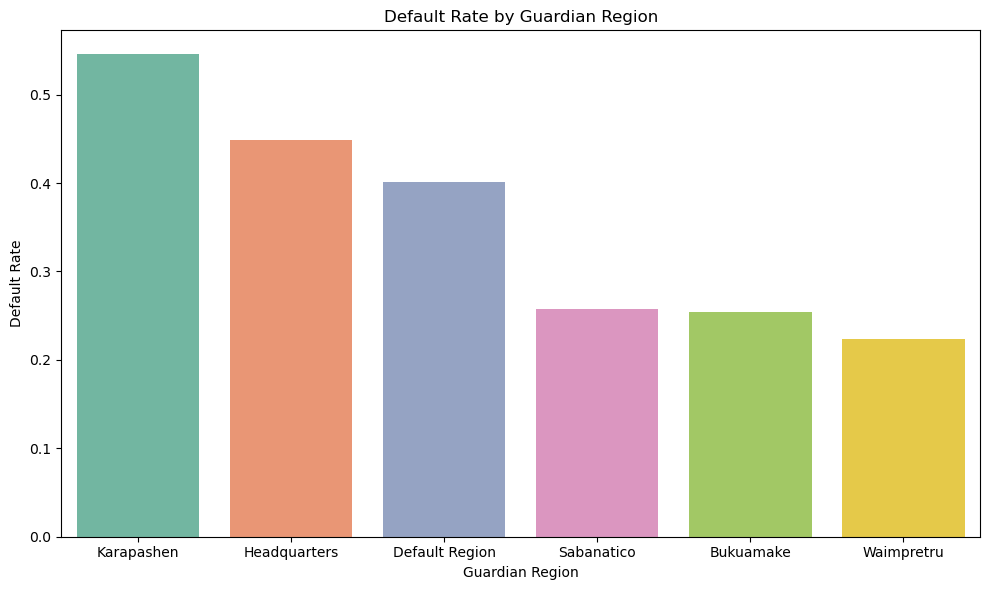

/var/folders/89/m3f4k_210_qd_2391fr69xr00000gn/T/ipykernel_97200/3071662388.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=guardian_sorted, x='Guardian Region', y='Avg Payments',palette='Set2')


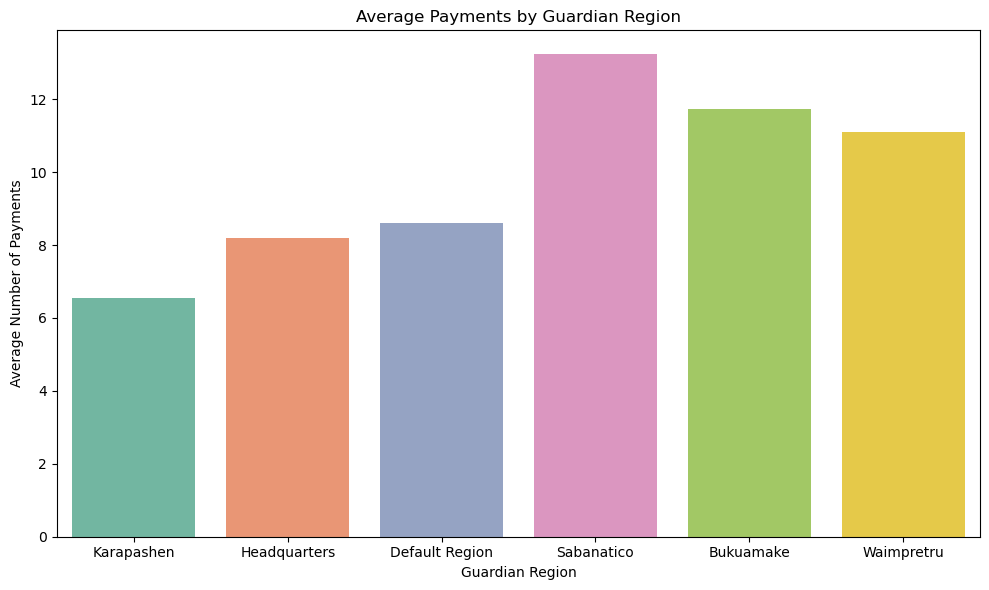

In [ ]:
# Recalculate guardian-level summary
guardian_summary = cleaned_df.groupby(['Reference Entity Name']).agg({
    'Id': 'count',
    'defaulted': 'mean',
    'num_payments': 'mean'
}).reset_index()
guardian_summary.columns = ['Guardian Region', 'Num Clients', 'Default Rate', 'Avg Payments']
guardian_sorted = guardian_summary.sort_values(by='Default Rate', ascending=False)

# Plot: Default Rate by Guardian Region
plt.figure(figsize=(10, 6))
sns.barplot(data=guardian_sorted, x='Guardian Region', y='Default Rate',palette='Set2')
plt.title('Default Rate by Guardian Region')
plt.ylabel('Default Rate')
plt.xlabel('Guardian Region')
plt.tight_layout()
plt.show()

# Plot: Average Payments by Guardian Region
plt.figure(figsize=(10, 6))
sns.barplot(data=guardian_sorted, x='Guardian Region', y='Avg Payments',palette='Set2')
plt.title('Average Payments by Guardian Region')
plt.ylabel('Average Number of Payments')
plt.xlabel('Guardian Region')
plt.tight_layout()
plt.show()


In [ ]:
cleaned_df.columns

Index(['Id', 'First Name', 'Family Name', 'Gender', 'Primary Phone Number',
       'All Phone Numbers', 'Start Date', 'Has Active Contracts',
       'Has Completed Contracts', 'Has Defaulted Contracts',
       'Has Late Contracts', 'L0 Entity Id', 'L0 Entity Name', 'L1 Entity Id',
       'L1 Entity Name', 'L2 Entity Id', 'L2 Entity Name', 'L3 Entity Id',
       'L3 Entity Name', 'L4 Entity Id', 'L4 Entity Name', 'Overpaid Amount',
       'User In Charge Id', 'Last Updated', 'defaulted', 'Client Id',
       'avg_days_late', 'max_days_late', 'total_paid', 'total_due',
       'num_payments', 'Role', 'Reference Entity Name'],
      dtype='object')

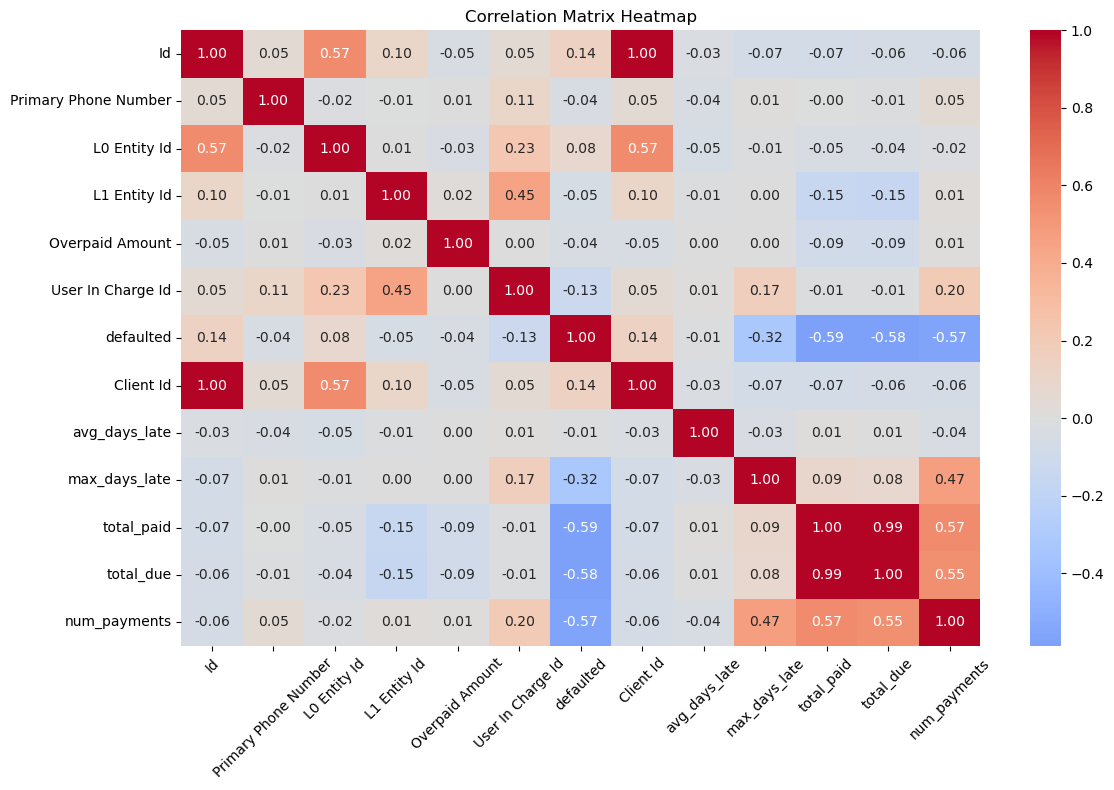

In [ ]:
# Filter numeric columns
numeric_df = cleaned_df.select_dtypes(include=['number']).drop(columns=['L2 Entity Id', 'L3 Entity Id', 'L4 Entity Id'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

features = cleaned_df[['avg_days_late', 'max_days_late', 'total_paid', 'total_due', 'num_payments']]
target = cleaned_df['defaulted']

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)
y = target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define parameter grids
logreg_params = {'C': [0.01, 0.1, 1, 10]}
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10]}
xgb_params = {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.1, 0.3]}


# GridSearchCV for Logistic Regression
logreg_grid = GridSearchCV(LogisticRegression(max_iter=1000), logreg_params, cv=5, scoring='f1', n_jobs=-1)
logreg_grid.fit(X_train_scaled, y_train)

# GridSearchCV for Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# GridSearchCV for XGBoost
xgb_grid = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42), xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

# Replace models with best estimators from tuning
models = {
    'Logistic Regression': logreg_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

# Step 6: Evaluate all models
results = []
for name, model in models.items():
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1 Score': report['1']['f1-score']
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.898396,0.964286,0.760563,0.850394
1,Random Forest,0.914439,0.936508,0.830986,0.880597
2,XGBoost,0.914439,0.950820,0.816901,0.878788


In [ ]:
cleaned_df.to_csv('cleaned_df.csv', index=False)


## Default probability of Clients

In [ ]:
# Train a Random Forest on the full dataset
from sklearn.ensemble import RandomForestClassifier
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X, target)

# Predict probabilities and labels
default_prob = rf_final.predict_proba(X)[:, 1]
predicted_labels = (default_prob >= 0.5).astype(int)


In [ ]:
# Add results to DataFrame
scored_df = cleaned_df.copy()
scored_df['predicted_default_prob'] = default_prob
scored_df['predicted_default_label'] = predicted_labels
scored_df

,Id,First Name,Family Name,Gender,Primary Phone Number,All Phone Numbers,Start Date,Has Active Contracts,Has Completed Contracts,Has Defaulted Contracts,...,Client Id,avg_days_late,max_days_late,total_paid,total_due,num_payments,Role,Reference Entity Name,predicted_default_prob,predicted_default_label
0,933,Ana,Epinayú Epinayú,Female,573206988017,+573206988017,2025-02-06 20:38,True,False,False,...,933.0,3.415000,8.05,105000.0,105000.0,3,Admin,Default Region,0.41,0
1,932,Brayan,Prueba,Male,573023997057,+573023997057,2025-02-04 18:36,True,False,False,...,932.0,NaN,NaN,35000.0,35000.0,1,SuperAdmin,Headquarters,0.29,0
2,931,Maye,Uriana,Female,573207921026,+573207921026,2024-09-15 18:07,True,False,False,...,931.0,6.712000,13.66,175000.0,175000.0,6,SuperAdmin,Headquarters,0.02,0
3,930,Diana Patricia,Uriana Urian,Female,573207921026,+573207921026,2024-09-15 17:52,True,False,False,...,930.0,6.714000,13.66,175000.0,175000.0,6,SuperAdmin,Headquarters,0.02,0
4,929,Rosiris Yosira,Uriana,Female,573207921026,+573207921026,2024-09-15 17:45,True,False,False,...,929.0,6.720000,13.66,175000.0,175000.0,6,SuperAdmin,Headquarters,0.02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
927,5,Epinayu,Ana Maria,Unknown,573023997057,+573023997057,2024-07-11 16:11,True,False,False,...,5.0,18.446667,265.27,245000.0,245000.0,4,Admin,Default Region,0.03,0
928,4,Epieyu,Oliverio,Unknown,573023997057,+573023997057,2024-07-11 16:11,False,False,True,...,4.0,-27.373333,20.02,280000.0,280000.0,10,Admin,Default Region,0.98,1
929,3,Epieyu,Uriana Enelisa,Unknown,573023997057,+573023997057,2024-07-11 16:11,True,False,False,...,3.0,8.416667,265.18,280000.0,280000.0,4,Admin,Default Region,0.02,0
930,2,Paula,Kisabo,Unknown,573216459877,+573216459877,2024-06-20 16:27,False,False,True,...,2.0,NaN,NaN,30000.0,30000.0,1,SuperAdmin,Headquarters,0.93,1
